In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 1. Import and prepare TPM counts datasets

In [9]:
# import PAM50 genes
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [3]:
# import tpm count files
train = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)
scanb_hiseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_test_20.csv", 
                          header=0, index_col=0)
scanb_nextseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_cleaned_data/pam50genes_tpm_counts_subtype_scanb_nextseq.csv", 
                          header=0, index_col=0)
tcga_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/pam50genes_tpm_counts_subtype_tcga_brca.csv", 
                       header=0, index_col=0)

In [4]:
# check dimension
print(train.shape)
print(scanb_hiseq_test.shape)
print(scanb_nextseq_test.shape)
print(tcga_test.shape)

(2204, 52)
(551, 52)
(276, 51)
(1031, 51)


In [5]:
train['subtype'] = train['subtype'].replace({'Her2': 'HER2'})
scanb_hiseq_test['subtype'] = scanb_hiseq_test['subtype'].replace({'Her2': 'HER2'})
scanb_nextseq_test['subtype'] = scanb_nextseq_test['subtype'].replace({'Her2': 'HER2'})
tcga_test['subtype'] = tcga_test['subtype'].replace({'Her2': 'HER2'})

In [6]:
train['subtype'].value_counts()

subtype
LumA     1119
LumB      654
Basal     230
HER2      201
Name: count, dtype: int64

In [7]:
# check whether the first 50 column names (PAM50 gene ensembl IDs) match
print(train.columns[0:50].equals(scanb_hiseq_test.columns[0:50]))
print(train.columns[0:50].equals(scanb_nextseq_test.columns[0:50]))
print(train.columns[0:50].equals(tcga_test.columns[0:50]))

True
True
True


In [10]:
# check whether the ensemble id column order match with that of in the pam50 df
train.columns[0:50].tolist() == pam50['ensembl_gene_id'].tolist()

True

In [11]:
# extract tpm counts
train_counts = train.iloc[:, 0:50]
scanb_hiseq_test_counts = scanb_hiseq_test.iloc[:, 0:50]
scanb_nextseq_test_counts = scanb_nextseq_test.iloc[:, 0:50]
tcga_test_counts = tcga_test.iloc[:, 0:50]

In [12]:
# rename columns from ensembl gene ids to gene symbols for visualization
train_counts.columns = pam50['new_gene_symbol'].tolist()
scanb_hiseq_test_counts.columns = pam50['new_gene_symbol'].tolist()
scanb_nextseq_test_counts.columns = pam50['new_gene_symbol'].tolist()
tcga_test_counts.columns = pam50['new_gene_symbol'].tolist()

In [13]:
# replace gene values by the rank
train_ranked = train_counts.rank(axis=1, method="min", ascending=False).astype('int')
scanb_hiseq_test_ranked = scanb_hiseq_test_counts.rank(axis=1, method="min", ascending=False).astype('int')
scanb_nextseq_test_ranked = scanb_nextseq_test_counts.rank(axis=1, method="min", ascending=False).astype('int')
tcga_test_ranked = tcga_test_counts.rank(axis=1, method="min", ascending=False).astype('int')

In [14]:
print(train_ranked.shape)
print(scanb_hiseq_test_ranked.shape)
print(scanb_nextseq_test_ranked.shape)
print(tcga_test_ranked.shape)

(2204, 50)
(551, 50)
(276, 50)
(1031, 50)


In [15]:
# merge gene ranks with subtypes
train_ranked_subtype_dataset = train_ranked.join(train.loc[:, ['subtype']])
scanb_hiseq_test_ranked_subtype_dataset = scanb_hiseq_test_ranked.join(scanb_hiseq_test.loc[:, ['subtype']])
scanb_nextseq_test_ranked_subtype_dataset = scanb_nextseq_test_ranked.join(scanb_nextseq_test.loc[:, ['subtype']])
tcga_test_ranked_subtype_dataset = tcga_test_ranked.join(tcga_test.loc[:, ['subtype']])

In [16]:
# add dataset column
train_ranked_subtype_dataset['dataset'] = 'SCAN-B HiSeq Train'
scanb_hiseq_test_ranked_subtype_dataset['dataset'] = 'SCAN-B HiSeq Test'
scanb_nextseq_test_ranked_subtype_dataset['dataset'] = 'SCAN-B NextSeq Test'
tcga_test_ranked_subtype_dataset['dataset'] = 'TCGA-BRCA Test'

In [17]:
# merge the datasets
merged_subtype_dataset = pd.concat([train_ranked_subtype_dataset, scanb_hiseq_test_ranked_subtype_dataset, 
                                    scanb_nextseq_test_ranked_subtype_dataset, tcga_test_ranked_subtype_dataset],
                                   axis=0)
merged_subtype_dataset.shape

(4062, 52)

In [18]:
# reshape from wide to long format
gene_columns = merged_subtype_dataset.columns[:-2]
merged_subtype_dataset_long = merged_subtype_dataset.melt(id_vars=['subtype', 'dataset'], value_vars=gene_columns, var_name='gene', value_name='ranks')

In [19]:
merged_subtype_dataset_long.shape

(203100, 4)

#### 2. Visualize rank of three genes with largest distribution shifts using boxplots
##### Genes: TYMS, MIA and MYC
##### Genes were determined based on KDE and KS-test analysis of gene-specific distribution between SCAN-B HiSeq training and TCGA-BRCA test sets

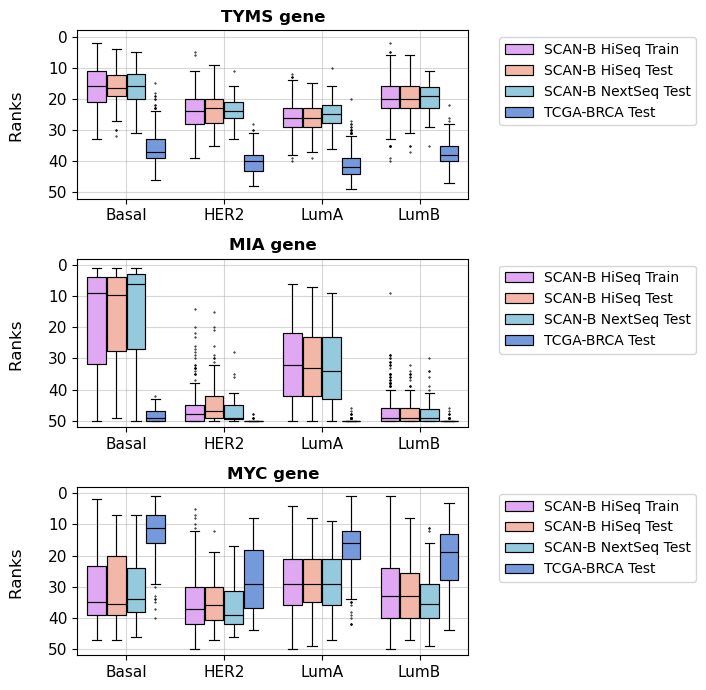

In [22]:
# plot boxplot
custom_order_subtype = ['Basal', 'HER2', 'LumA', 'LumB']
custom_palette = {'SCAN-B HiSeq Train': '#e79aff',
                  'SCAN-B HiSeq Test': '#FFB09C',
                  'SCAN-B NextSeq Test': '#87CEEB',
                  'TCGA-BRCA Test': '#6495ED'}
diff_genes = ['TYMS', 'MIA', 'MYC']
plt.figure(figsize=(9,7))
for i in range(len(diff_genes)):
    plt.subplot(3, 1, i+1)
    data = merged_subtype_dataset_long.loc[(merged_subtype_dataset_long['gene']==diff_genes[i])]
    sns.boxplot(x='subtype', y='ranks', hue='dataset', data=data, gap=0.05, linewidth=0.85,
               palette=custom_palette, order=custom_order_subtype, fliersize=0.5, linecolor='black', width=0.8)
    plt.title(f'{diff_genes[i]} gene', fontdict={'size':12, 'color':'black', 'family':'sans-serif', 'weight': 'bold'})
    plt.xlabel('',fontsize=12, color='black', fontfamily='sans-serif')
    plt.ylabel('Ranks \n ', fontsize=12, color='black', fontfamily='sans-serif')
    plt.legend(title='', bbox_to_anchor=(1.6,1),loc='upper right', ncol=1, fontsize=10)
    plt.ylim(52, -2)
    plt.xticks(fontsize=11, color='black', fontfamily='sans-serif', rotation=0)
    plt.yticks(fontsize=11, color='black', fontfamily='sans-serif')
    plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('rank_distribution_most_variable_genes.png', dpi=300, bbox_inches='tight')
plt.show()

#### 3. Visualize rank distribution of three genes with smallest distribution shifts using boxplots
##### Genes: CDC20, BAG1, FGFR4
##### Genes were determined based on KDE and KS-test analysis of gene-specific distribution between SCAN-B HiSeq training and TCGA-BRCA test sets

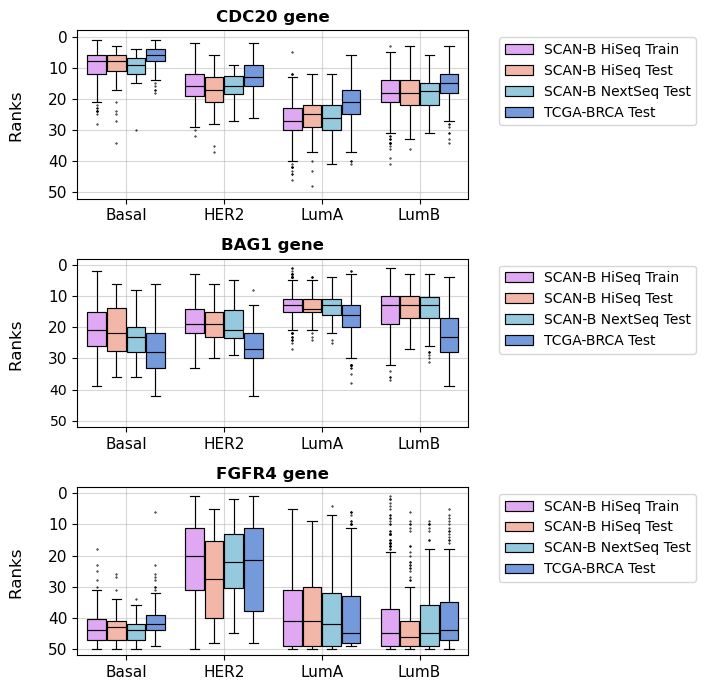

In [23]:
# plot boxplot
custom_order_subtype = ['Basal', 'HER2', 'LumA', 'LumB']
custom_palette = {'SCAN-B HiSeq Train': '#e79aff',
                  'SCAN-B HiSeq Test': '#FFB09C',
                  'SCAN-B NextSeq Test': '#87CEEB',
                  'TCGA-BRCA Test': '#6495ED'}
diff_genes = ['CDC20', 'BAG1', 'FGFR4']
plt.figure(figsize=(9,7))
for i in range(len(diff_genes)):
    plt.subplot(3, 1, i+1)
    data = merged_subtype_dataset_long.loc[(merged_subtype_dataset_long['gene']==diff_genes[i])]
    sns.boxplot(x='subtype', y='ranks', hue='dataset', data=data, gap=0.05, linewidth=0.85,
               palette=custom_palette, order=custom_order_subtype, fliersize=0.5, linecolor='black', width=0.8)
    plt.title(f'{diff_genes[i]} gene', fontdict={'size':12, 'color':'black', 'family':'sans-serif', 'weight': 'bold'})
    plt.xlabel('',fontsize=12, color='black', fontfamily='sans-serif')
    plt.ylabel('Ranks \n ', fontsize=12, color='black', fontfamily='sans-serif')
    plt.legend(title='', bbox_to_anchor=(1.6,1),loc='upper right', ncol=1, fontsize=10)
    plt.ylim(52, -2)
    plt.xticks(fontsize=11, color='black', fontfamily='sans-serif', rotation=0)
    plt.yticks(fontsize=11, color='black', fontfamily='sans-serif')
    plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('rank_distribution_least_variable_genes.png', dpi=300, bbox_inches='tight')
plt.show()